In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

## RNN Model Design (MNIST-RNN)

### **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

### **DataSet**

#### Load

In [4]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
mnist_transform = transforms.ToTensor()

from torchvision.datasets import MNIST

download_root = './MNIST_DATASET'
batch_size = 512

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.25MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.81MB/s]


### **Model-3 : Hierachical RNN model**


#### Model Define

In [5]:
# 주요 변수 정의
pixel = 1          ## features
pixels = 28        ## pixels
lines = 28         ## lines
chennels = 1       ## b/w = 1
lstm1_units = 50    #50 임의 값
lstm2_units = 16   # 임의 값
out_dense = 10   # 출력은 숫자(0~9) 확률

In [6]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.to(device)(x)
        y = y.squeeze(dim=-1)
        loss = F.cross_entropy(y_hat, y)
        acc = FM.accuracy(y_hat, y,task='multiclass',num_classes=10 )
        metrics = {'loss':loss, 'acc':acc}
        self.log_dict(metrics, prog_bar=True, on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.to(device)(x)
        y = y.squeeze(dim=-1)
        loss = F.cross_entropy(logits, y)
        acc = FM.accuracy(logits, y.long(),task='multiclass',num_classes=10 )
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True, on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [7]:
class HierarchicalRNN(Wrap_10):
    def __init__(self, pixel, lstm1_units, lstm2_units, out_dense, batch_first=True):
        super(HierarchicalRNN, self).__init__()
        self.timeDistributed_LSTM = nn.LSTM(input_size=pixel, hidden_size=lstm1_units,
                                            batch_first=batch_first)
        self.lstm = nn.LSTM(input_size=lstm1_units, hidden_size=lstm2_units,
                                            batch_first=batch_first)
        self.outLinear = nn.Linear(lstm2_units, out_dense)

    def forward(self, x):
        # x1:([512, 28p, 1]) <- x:([512, 1, 28l, 28p])
        x1 = x[:,0,0,:].reshape(x.size(0),-1,1)
        y = self.timeDistributed_LSTM(x1) #([512, 28, 50])
        y = y[0][:,-1,:] #(512,50)
        y = y.view(x.size(0),1,-1) #(512,1,50)
        for i in range(x.size()[2]-1):
          x1 = x[:,0,i+1,:].reshape(x.size(0),-1,1)
          y1 = self.timeDistributed_LSTM(x1)
          y1 = y1[0][:,-1,:] #(512,50)
          y1 = y1.view(x.size(0),1,-1) #(512,1,50)
          y = torch.cat((y, y1),dim=1)
        #y: ([512, 28, 50])
        out, (hn, cn) = self.lstm(y) #(512,28,16)
        out = self.outLinear(out[:, -1, :]) #(512,10)
        return out

model = HierarchicalRNN(pixel, lstm1_units, lstm2_units, out_dense)
summary(model, input_size=(batch_size, chennels, lines, pixels)) #(bs,1,28,28)

Layer (type:depth-idx)                   Output Shape              Param #
HierarchicalRNN                          [512, 10]                 --
├─LSTM: 1-1                              [512, 28, 50]             10,600
├─LSTM: 1-2                              [512, 28, 50]             (recursive)
├─LSTM: 1-3                              [512, 28, 50]             (recursive)
├─LSTM: 1-4                              [512, 28, 50]             (recursive)
├─LSTM: 1-5                              [512, 28, 50]             (recursive)
├─LSTM: 1-6                              [512, 28, 50]             (recursive)
├─LSTM: 1-7                              [512, 28, 50]             (recursive)
├─LSTM: 1-8                              [512, 28, 50]             (recursive)
├─LSTM: 1-9                              [512, 28, 50]             (recursive)
├─LSTM: 1-10                             [512, 28, 50]             (recursive)
├─LSTM: 1-11                             [512, 28, 50]             (re

#### Fit

In [8]:
%%time
model = HierarchicalRNN(pixel, lstm1_units, lstm2_units, out_dense)

name = "HierarchicalRNN"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=30, logger=logger,)
trainer.fit(model, train_loader, test_loader)
# Wall time: 2min 45s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


CPU times: user 2min 30s, sys: 7.88 s, total: 2min 38s
Wall time: 2min 43s


#### **Analysis**

##### Plot

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)
print('\t',df['val_acc'].max())

	 0.9641000032424928


In [ ]:
plt.title(f"{name}\nMax Acc:{df['val_acc'].max():.3f}")
plt.plot(df['acc'], label="acc")
plt.plot(df['val_acc'], label="val_acc")
plt.plot(df['loss'], label="loss")
plt.plot(df['val_loss'], label="val_loss")
plt.ylim(0.,1.1)
#plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

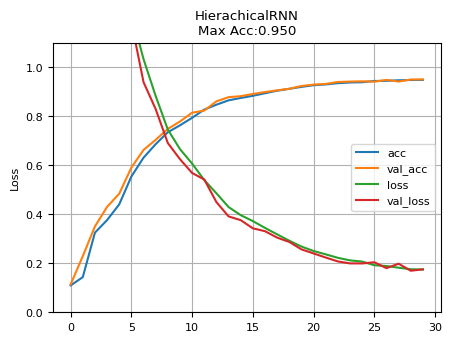

### ***실습 과제***  
##### 과제 1.: Model_3 변형 : LSTM_1의 units이 적절할까? 너무 큰것 아닐까? 줄여보자.
- 최적의 units이 얼마일까? 최적인 이유는?
- Parameter의 수의 차이도 확인해 보자

##### 과제 2: in_Dense Layer와 LSTM1 Layer 성능 비교     
- model1에서 in-Dense Layer와 model3에서 LSTM1의 역할과 성능 비교 하기   
- 동일한 수준의 parameter를 가질때 성능차이 확인 하기  

##### 과제 3: in_Dense Layer와 Conv. Layer 성능 비교     
- model1에서 in-Dense Layer를 Conv. Layer로 대체하여 역할과 성능 비교 하기
- 동일한 수준의 parameter를 가질때 성능차이 확인 하기  


#### 과제 1


#### Model Define

In [ ]:
# 주요 변수 재정의
lstm1_units = 8    # <-50
lstm2_units = 56   # <-16

In [ ]:
model = HierarchicalRNN(pixel, lstm1_units, lstm2_units, out_dense)
summary(model, input_size=(batch_size, chennels, lines, pixels)) #(bs,1,28,28)

#### Fit

In [ ]:
%%time
model = HierarchicalRNN(pixel, lstm1_units, lstm2_units, out_dense).to(device)

name = "HierachicalRNN2"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=30, logger=logger,)
trainer.fit(model, train_loader, test_loader)

#### **Analysis**

##### Plot

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df2 = history.groupby('epoch').last().drop('step', axis=1)
print('\t',df2['val_acc'].max())

	 0.9569000005722046


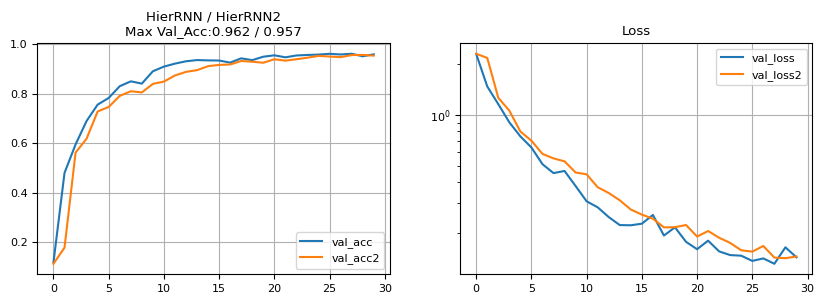

In [ ]:
plt.figure(figsize=(10,3))
title = "HierRNN / HierRNN2"
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{df['val_acc'].max():.3f} / {df2['val_acc'].max():.3f}")
plt.plot(df['val_acc'], label='val_acc')
plt.plot(df2['val_acc'], label='val_acc2')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(df['val_loss'], label='val_loss')
plt.plot(df2['val_loss'], label='val_loss2')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()